<a href="https://colab.research.google.com/github/karunachawla000/Heart-Disease-Predictor/blob/main/HEART_DISEASE_PREDICTOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===============================
# HEART DISEASE PREDICTION PROJECT
# ===============================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Upload Dataset (Option 2)
from google.colab import files
uploaded = files.upload()

# Step 3: Load Dataset
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

Saving heart_disease_uci.csv to heart_disease_uci.csv


In [2]:
print("Columns in dataset:", df.columns)
print(df.head())

Columns in dataset: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    ups

In [3]:
# Step 4: Fix Target Column
if 'target' not in df.columns:
    if 'num' in df.columns:
        df.rename(columns={'num': 'target'}, inplace=True)
    elif 'output' in df.columns:
        df.rename(columns={'output': 'target'}, inplace=True)
    elif 'condition' in df.columns:
        df.rename(columns={'condition': 'target'}, inplace=True)


In [4]:
# Convert target to binary (important)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)


In [5]:
# Step 5: Convert categorical data automatically
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes


In [6]:
import pandas as pd

# Create a sample DataFrame with a categorical column
sample_data = {'ID': [1, 2, 3, 4],
               'Color': ['Red', 'Blue', 'Red', 'Green'],
               'Size': ['Small', 'Large', 'Medium', 'Small']}
sample_df = pd.DataFrame(sample_data)

print("Original DataFrame:")
display(sample_df)
print("Data Types Before Encoding:")
print(sample_df.dtypes)

# Apply the categorical encoding logic to the sample DataFrame
for col in sample_df.columns:
    if sample_df[col].dtype == 'object':
        sample_df[col] = sample_df[col].astype('category').cat.codes

print("\nDataFrame After Categorical Encoding:")
display(sample_df)
print("Data Types After Encoding:")
print(sample_df.dtypes)

Original DataFrame:


,ID,Color,Size
0,1,Red,Small
1,2,Blue,Large
2,3,Red,Medium
3,4,Green,Small


Data Types Before Encoding:
ID        int64
Color    object
Size     object
dtype: object

DataFrame After Categorical Encoding:


,ID,Color,Size
0,1,2,2
1,2,0,0
2,3,2,1
3,4,1,2


Data Types After Encoding:
ID       int64
Color     int8
Size      int8
dtype: object


In [7]:
# Step 6: Handle Missing Values
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)


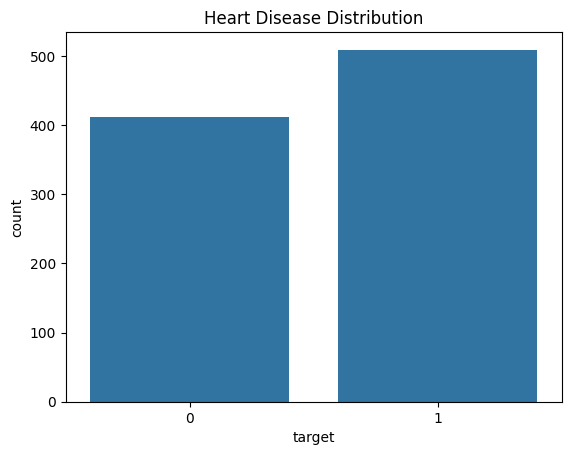

In [8]:
# Step 7: EDA

# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

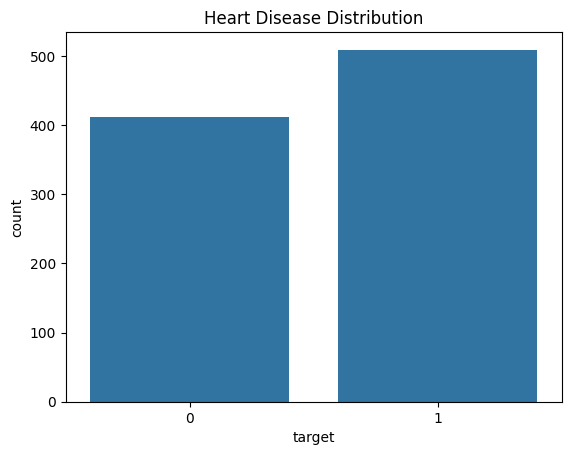

In [9]:
# Step 7: EDA

# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

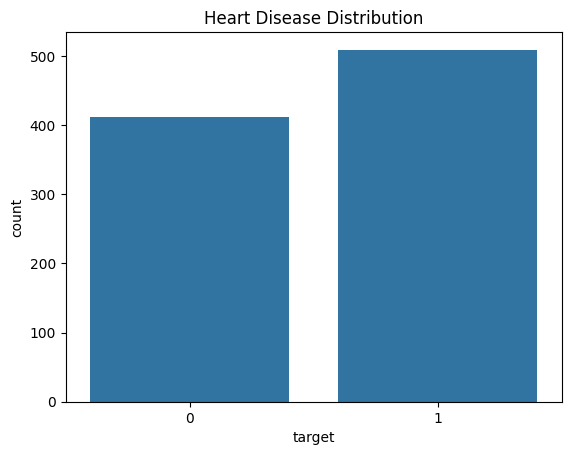

In [10]:
# Step 7: EDA

# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

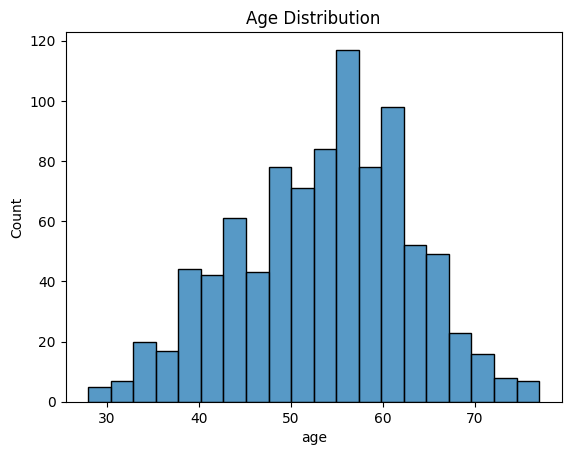

In [11]:
# Age Distribution (if exists)
if 'age' in df.columns:
    sns.histplot(df['age'], bins=20)
    plt.title("Age Distribution")
    plt.show()

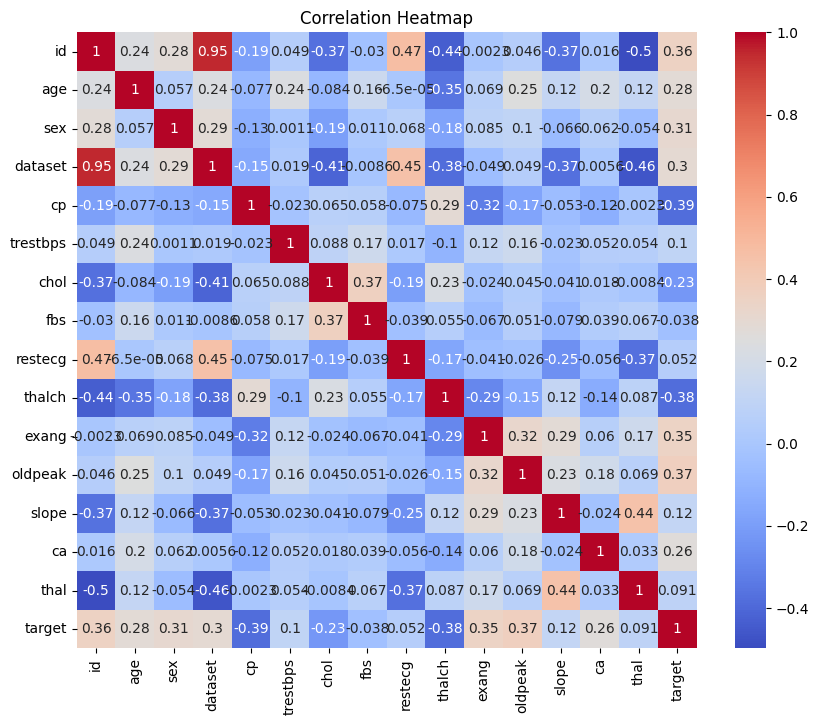

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Step 8: Feature & Target Split
X = df.drop('target', axis=1)
y = df['target']

In [14]:
# Step 9: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Step 10: Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Step 11: Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [17]:
# Step 12: Prediction
y_pred = model.predict(X_test)


In [18]:
# Step 13: Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7880434782608695

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.84      0.76        75
           1       0.87      0.75      0.81       109

    accuracy                           0.79       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.79      0.79       184



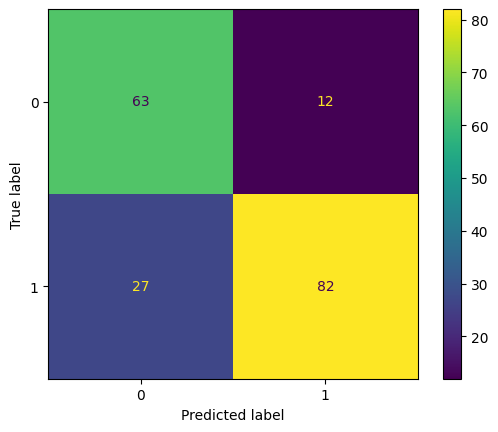

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()